<a href="https://colab.research.google.com/github/krishnamohan15/Customer-Churn-Prediction-System/blob/main/Customer_Churn_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("/content/customer_churn_dataset-testing-master.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (64374, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [ ]:
# Basic information about the dataset

print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nChurn Distribution:")
print(df["Churn"].value_counts())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB
None

Missing Values:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Pa

EDA: Churn distribution

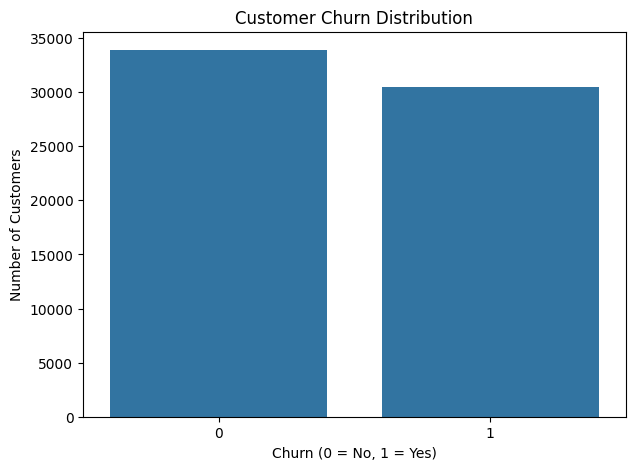

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Churn distribution
plt.figure(figsize=(7, 5))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

Analyze numeric features

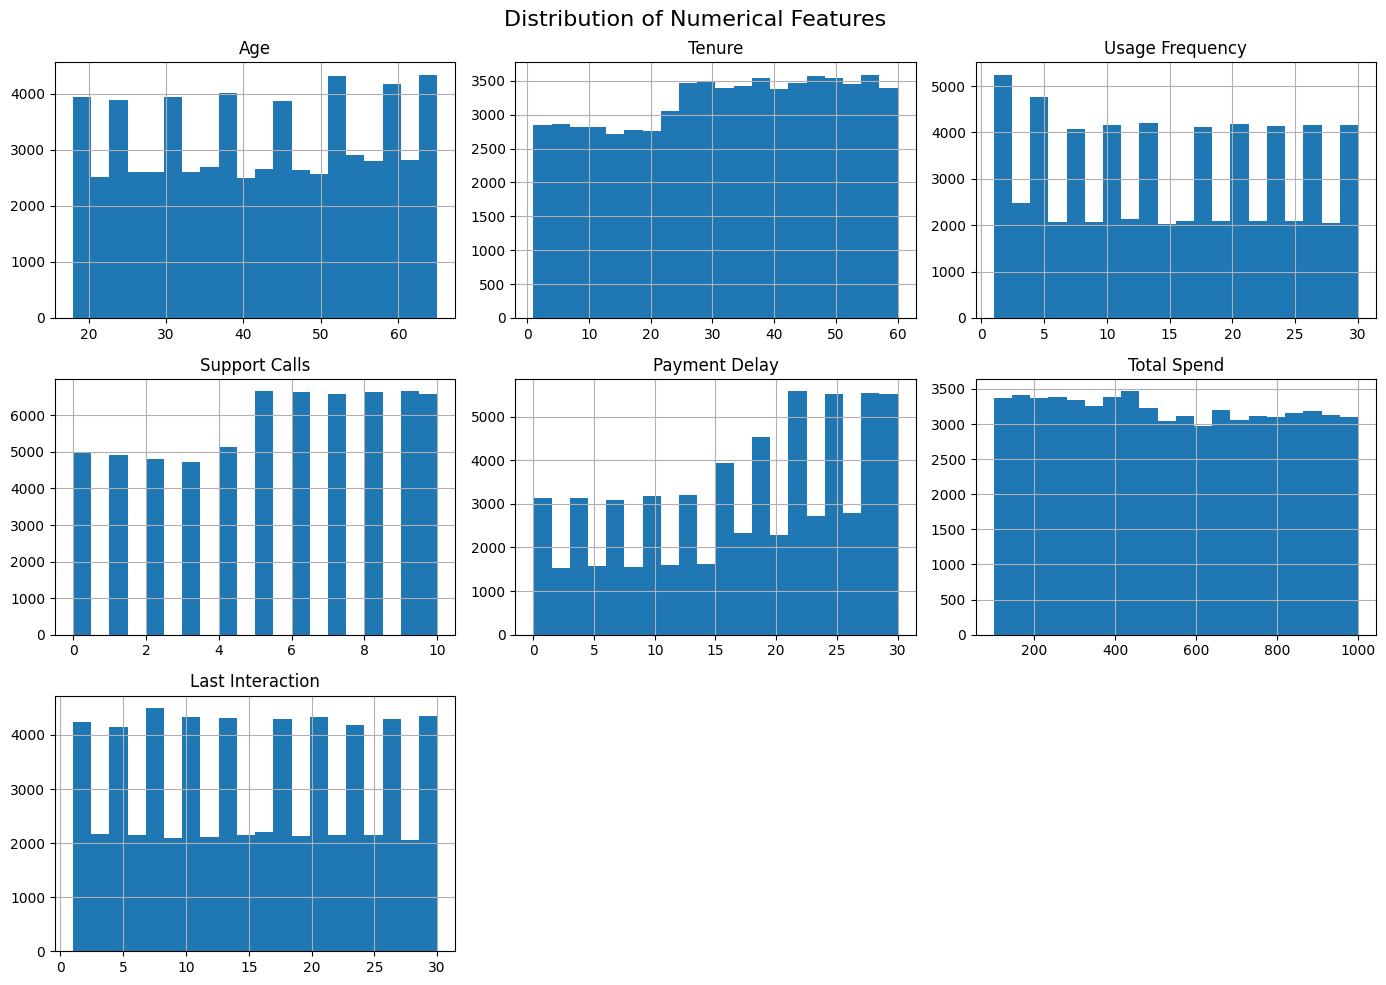

In [ ]:
# Distribution of important numerical features

numeric_columns = [
    "Age",
    "Tenure",
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Total Spend",
    "Last Interaction"
]

df[numeric_columns].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

Categorical Feature Analysis

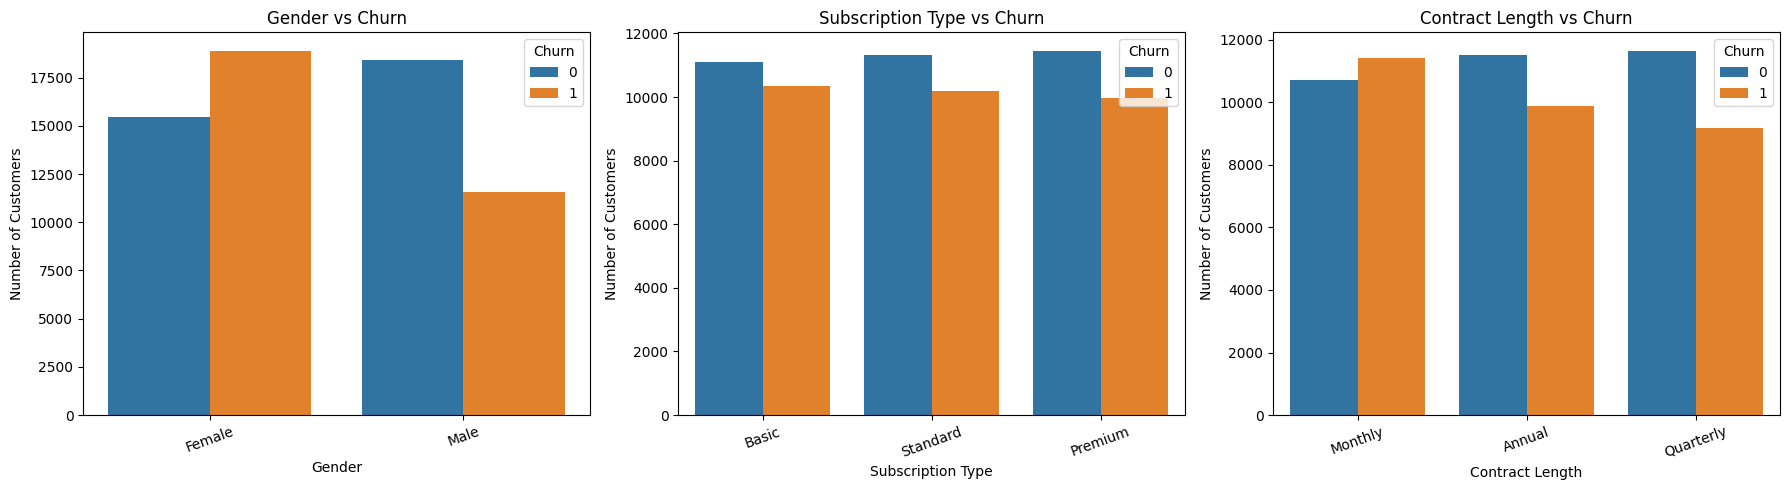

In [ ]:
# Categorical feature analysis

categorical_columns = [
    "Gender",
    "Subscription Type",
    "Contract Length"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(categorical_columns):
    sns.countplot(
        data=df,
        x=col,
        hue="Churn",
        ax=axes[i]
    )
    axes[i].set_title(f"{col} vs Churn")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Number of Customers")
    axes[i].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

Churn rate by categories

In [ ]:
# Churn rate by categorical features

for col in ["Gender", "Subscription Type", "Contract Length"]:
    churn_rate = df.groupby(col)["Churn"].mean() * 100

    print(f"\nChurn Rate by {col}:")
    print(churn_rate.round(2))


Churn Rate by Gender:
Gender
Female    55.05
Male      38.58
Name: Churn, dtype: float64

Churn Rate by Subscription Type:
Subscription Type
Basic       48.28
Premium     46.50
Standard    47.33
Name: Churn, dtype: float64

Churn Rate by Contract Length:
Contract Length
Annual       46.22
Monthly      51.61
Quarterly    44.05
Name: Churn, dtype: float64


Correlation Analysis

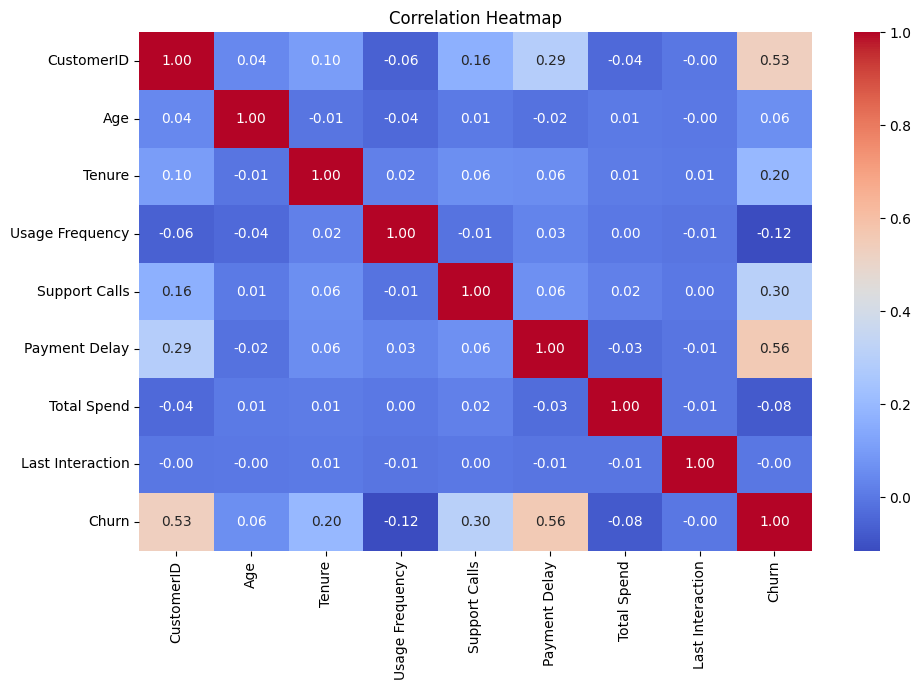

In [ ]:
# Correlation analysis for numerical features

plt.figure(figsize=(10, 7))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Analyze customer behavior

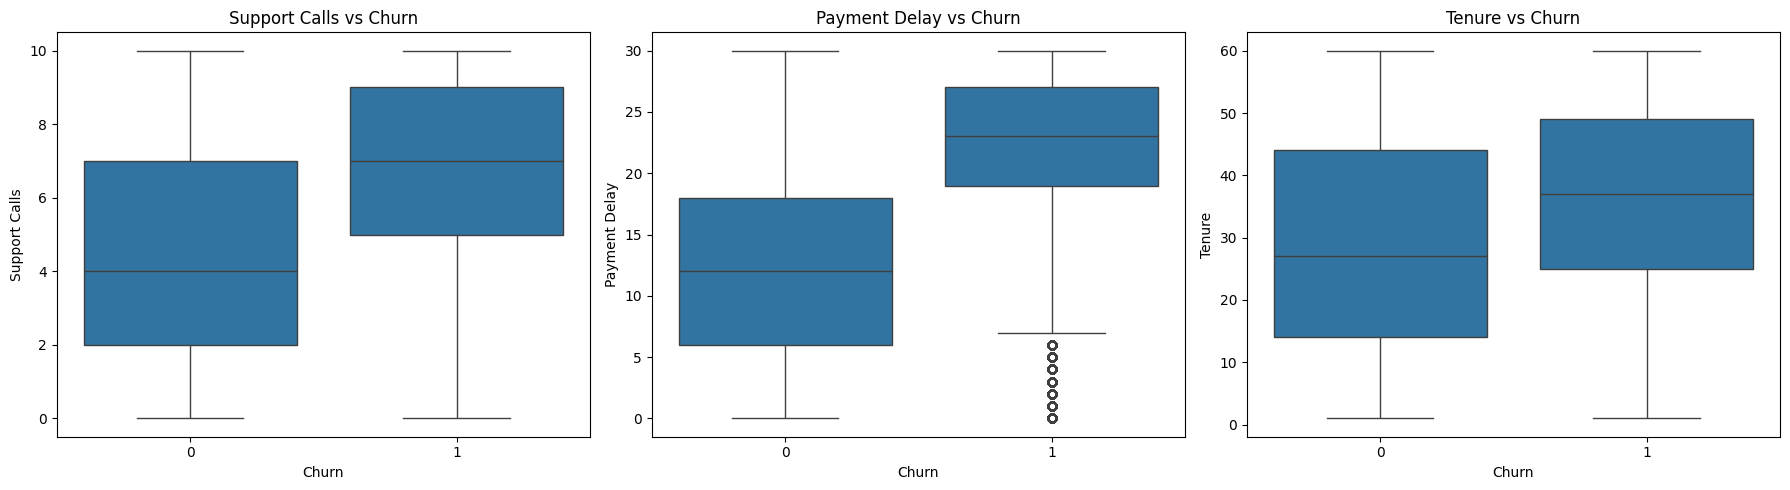

In [ ]:
# Customer behavior analysis

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x="Churn", y="Support Calls", ax=axes[0])
axes[0].set_title("Support Calls vs Churn")

sns.boxplot(data=df, x="Churn", y="Payment Delay", ax=axes[1])
axes[1].set_title("Payment Delay vs Churn")

sns.boxplot(data=df, x="Churn", y="Tenure", ax=axes[2])
axes[2].set_title("Tenure vs Churn")

plt.tight_layout()
plt.show()

Prepare data for Machine Learning

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Remove CustomerID because it is only an identifier
X = df.drop(columns=["CustomerID", "Churn"])
y = df["Churn"]

# Identify columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']

Categorical Features:
['Gender', 'Subscription Type', 'Contract Length']


Train/Test Split

In [ ]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (51499, 10)
Testing data: (12875, 10)


Create preprocessing pipeline

In [ ]:
# Preprocessing pipelines

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


Train Model 1: Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_pipeline.fit(X_train, y_train)

y_pred_logistic = logistic_pipeline.predict(X_test)

print("Logistic Regression Results")
print("Accuracy :", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall   :", recall_score(y_test, y_pred_logistic))
print("F1 Score :", f1_score(y_test, y_pred_logistic))

Logistic Regression Results
Accuracy : 0.8270291262135923
Precision: 0.8136746597537265
Recall   : 0.823413674372848
F1 Score : 0.8185151984353354


Train Model 2: Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest Results")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Random Forest Results
Accuracy : 0.9985242718446602
Precision: 0.9995070653959908
Recall   : 0.9973766191178882
F1 Score : 0.9984407057858022


Train Model 3: Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=10
    ))
])

dt_pipeline.fit(X_train, y_train)

y_pred_dt = dt_pipeline.predict(X_test)

print("Decision Tree Results")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

Decision Tree Results
Accuracy : 0.9983689320388349
Precision: 0.9970559371933267
Recall   : 0.999508116084604
F1 Score : 0.9982805207565709


Train Model 4: KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)

y_pred_knn = knn_pipeline.predict(X_test)

print("KNN Results")
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))

KNN Results
Accuracy : 0.9110679611650485
Precision: 0.8804915514592934
Recall   : 0.9398262010165601
F1 Score : 0.909191847093346


Create Model Comparison Table

In [ ]:
# Model comparison

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Decision Tree",
        "KNN"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_knn)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_knn)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_knn)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_knn)
    ]
})

results.iloc[:, 1:] = results.iloc[:, 1:] * 100

results.round(2)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,82.70,81.37,82.34,81.85
1,Random Forest,99.85,99.95,99.74,99.84
2,Decision Tree,99.84,99.71,99.95,99.83
3,KNN,91.11,88.05,93.98,90.92


Confusion Matrices

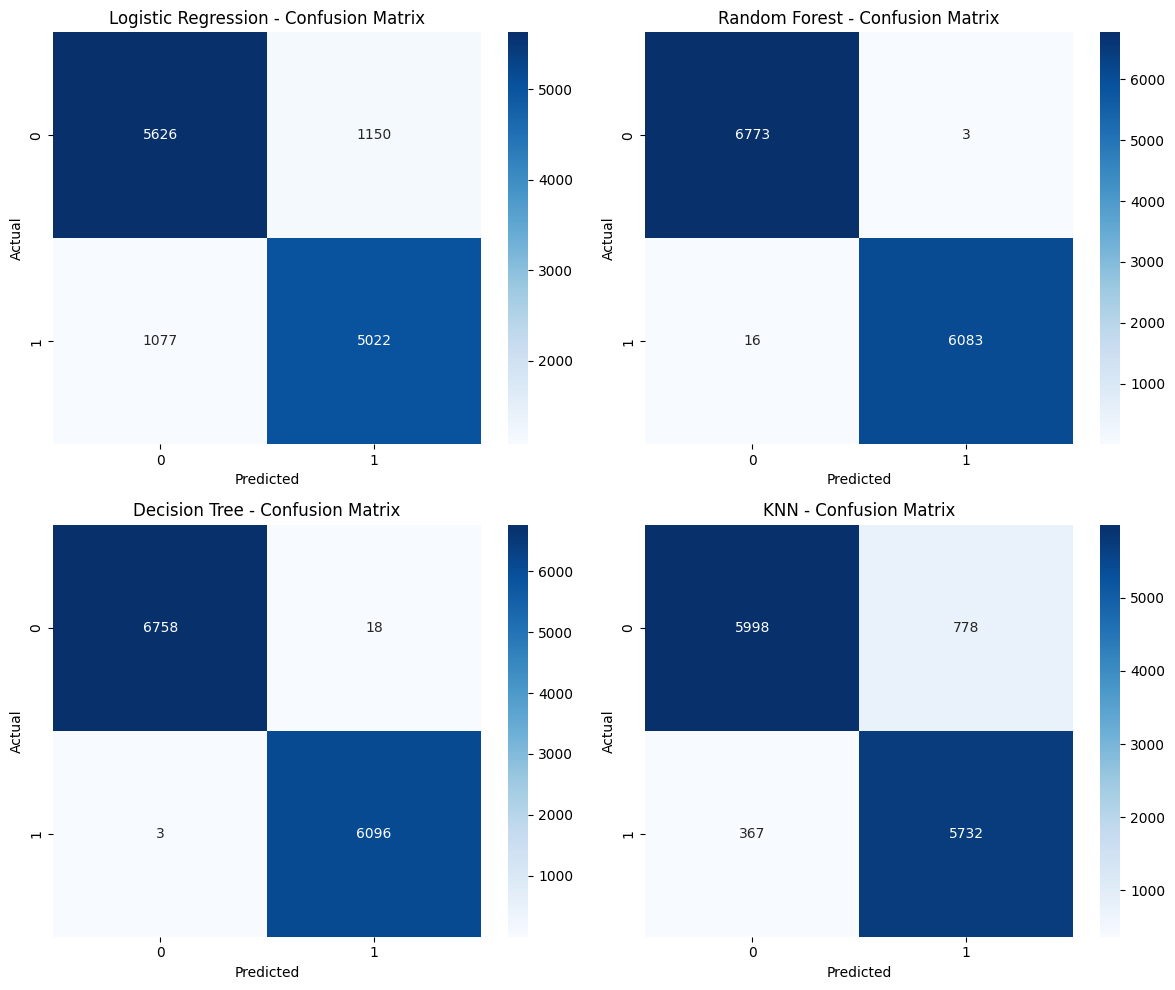

In [ ]:
from sklearn.metrics import confusion_matrix

models_predictions = {
    "Logistic Regression": y_pred_logistic,
    "Random Forest": y_pred_rf,
    "Decision Tree": y_pred_dt,
    "KNN": y_pred_knn
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, predictions) in zip(axes.ravel(), models_predictions.items()):
    cm = confusion_matrix(y_test, predictions)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(f"{name} - Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

Classification Reports

In [ ]:
from sklearn.metrics import classification_report

print("========== LOGISTIC REGRESSION ==========")
print(classification_report(y_test, y_pred_logistic))

print("========== RANDOM FOREST ==========")
print(classification_report(y_test, y_pred_rf))

print("========== DECISION TREE ==========")
print(classification_report(y_test, y_pred_dt))

print("========== KNN ==========")
print(classification_report(y_test, y_pred_knn))

========== LOGISTIC REGRESSION ==========
              precision    recall  f1-score   support

           0       0.84      0.83      0.83      6776
           1       0.81      0.82      0.82      6099

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875

========== RANDOM FOREST ==========
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6776
           1       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875

========== DECISION TREE ==========
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6776
           1       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg  

In [ ]:
# Check target relationship with numerical features

print("Correlation with Churn:")
print(
    df.select_dtypes(include=["int64", "float64"])
      .corr()["Churn"]
      .sort_values(ascending=False)
)

Correlation with Churn:
Churn               1.000000
Payment Delay       0.557386
CustomerID          0.529832
Support Calls       0.304631
Tenure              0.195327
Age                 0.063457
Last Interaction   -0.002818
Total Spend        -0.078867
Usage Frequency    -0.115098
Name: Churn, dtype: float64


Random Forest Feature Importance

In [ ]:
# Random Forest feature importance

rf_model = rf_pipeline.named_steps["model"]
rf_preprocessor = rf_pipeline.named_steps["preprocessor"]

feature_names = rf_preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Important Features:")
display(importance.head(15))

Top 15 Important Features:


,Feature,Importance
4,num__Payment Delay,0.434901
3,num__Support Calls,0.165593
1,num__Tenure,0.115492
2,num__Usage Frequency,0.084602
5,num__Total Spend,0.051998
0,num__Age,0.040487
8,cat__Gender_Male,0.032717
7,cat__Gender_Female,0.027171
6,num__Last Interaction,0.012991
13,cat__Contract Length_Monthly,0.012928


Graph of it:

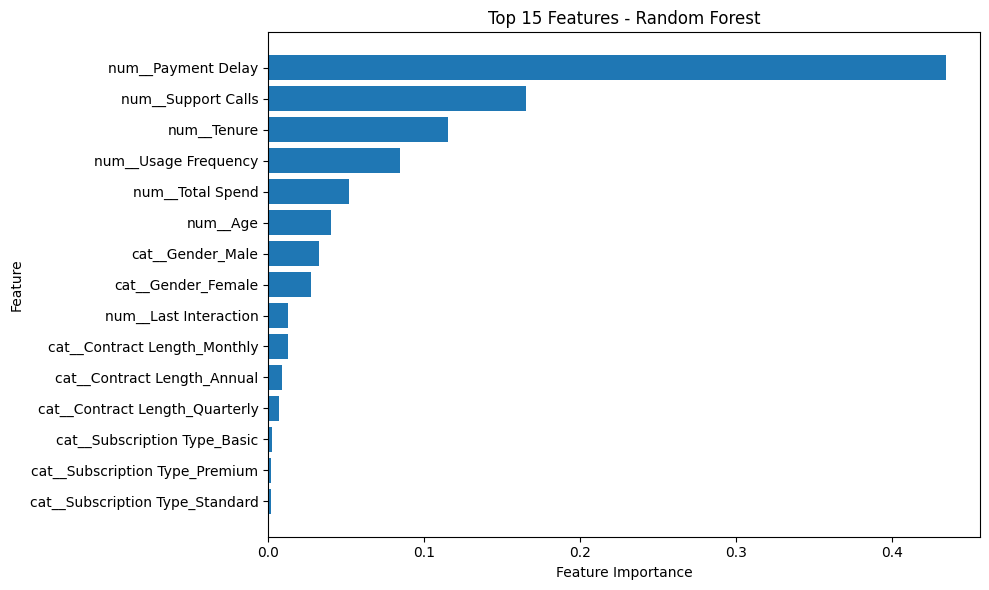

In [ ]:
plt.figure(figsize=(10, 6))

top_features = importance.head(15).sort_values("Importance")

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - Random Forest")
plt.tight_layout()
plt.show()

Check for the high accuracy to be reproducible

In [ ]:
# Check performance using a completely separate split

from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=123,
    stratify=y
)

rf_check = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=123,
        n_jobs=-1
    ))
])

rf_check.fit(X_train2, y_train2)

y_check = rf_check.predict(X_test2)

print("New Random Forest Accuracy:",
      accuracy_score(y_test2, y_check))

print("New Random Forest F1:",
      f1_score(y_test2, y_check))

New Random Forest Accuracy: 0.9993009708737864
New Random Forest F1: 0.9992621136345002


Check churn patterns by important variables

In [ ]:
# Average churn rate by important numerical variables

print("Average Churn by Payment Delay:")
print(df.groupby("Payment Delay")["Churn"].mean().round(3))

print("\nAverage Churn by Support Calls:")
print(df.groupby("Support Calls")["Churn"].mean().round(3))

print("\nAverage Churn by Tenure:")
print(df.groupby("Tenure")["Churn"].mean().round(3))

Average Churn by Payment Delay:
Payment Delay
0     0.096
1     0.096
2     0.116
3     0.108
4     0.098
5     0.098
6     0.088
7     0.108
8     0.099
9     0.104
10    0.097
11    0.105
12    0.097
13    0.100
14    0.106
15    0.102
16    0.579
17    0.596
18    0.580
19    0.583
20    0.590
21    0.772
22    0.762
23    0.778
24    0.757
25    0.768
26    0.763
27    0.762
28    0.756
29    0.770
30    0.771
Name: Churn, dtype: float64

Average Churn by Support Calls:
Support Calls
0     0.242
1     0.229
2     0.232
3     0.248
4     0.318
5     0.605
6     0.606
7     0.618
8     0.610
9     0.609
10    0.607
Name: Churn, dtype: float64

Average Churn by Tenure:
Tenure
1     0.362
2     0.353
3     0.334
4     0.347
5     0.343
6     0.305
7     0.318
8     0.298
9     0.272
10    0.307
11    0.306
12    0.272
13    0.277
14    0.283
15    0.281
16    0.265
17    0.296
18    0.293
19    0.278
20    0.282
21    0.281
22    0.319
23    0.281
24    0.563
25    0.551
26    0.544
27

Check CustomerID pattern

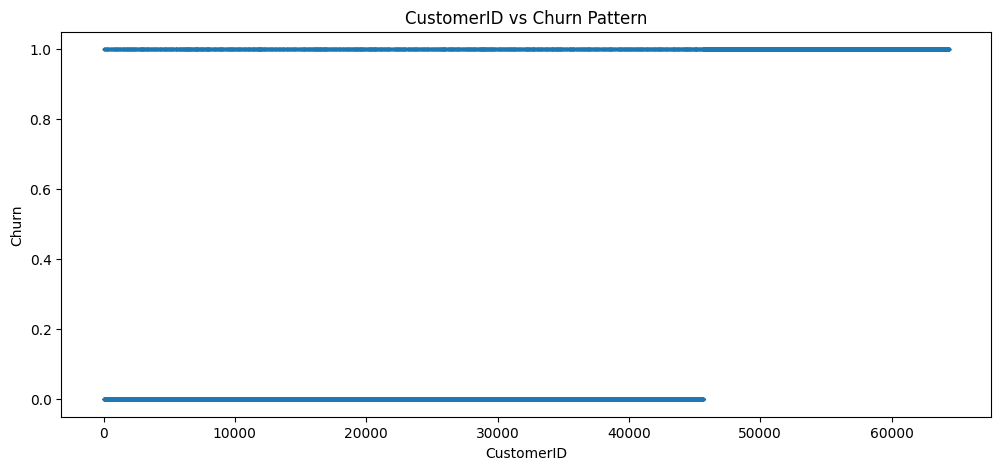

In [ ]:
# Check whether CustomerID is associated with churn ordering

plt.figure(figsize=(12, 5))

plt.scatter(
    df["CustomerID"],
    df["Churn"],
    s=2,
    alpha=0.3
)

plt.xlabel("CustomerID")
plt.ylabel("Churn")
plt.title("CustomerID vs Churn Pattern")
plt.show()

Cross-validation check

In [ ]:
import os

for root, dirs, files in os.walk("/"):
    for file in files:
        if file.endswith(".csv") and "churn" in file.lower():
            print(os.path.join(root, file))

/customer_churn_dataset-testing-master.csv


In [ ]:
import pandas as pd

df = pd.read_csv("/customer_churn_dataset-testing-master.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (64374, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [ ]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Columns:
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']

Missing values:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

Data types:
CustomerID            int64
Age                   int64
Gender               object
Tenure                int64
Usage Frequency       int64
Support Calls         int64
Payment Delay         int64
Subscription Type    object
Contract Length      object
Total Spend           int64
Last Interaction      int64
Churn                 int64
dtype: object


In [ ]:
# Remove CustomerID because it is only an identifier
X = df.drop(columns=["CustomerID", "Churn"])
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (64374, 10)
y shape: (64374,)

Target distribution:
Churn
0    33881
1    30493
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (51499, 10)
Testing data: (12875, 10)


Preprocessing

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Identify numerical and categorical columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("\nPreprocessor created successfully!")

Numerical features:
['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']

Categorical features:
['Gender', 'Subscription Type', 'Contract Length']

Preprocessor created successfully!


Random Forest Pipeline

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

print("Random Forest pipeline created successfully!")

Random Forest pipeline created successfully!


Train Random Forest

In [ ]:
print("Training Random Forest...")
rf_pipeline.fit(X_train, y_train)

print("Random Forest training completed!")

Training Random Forest...
Random Forest training completed!


Evaluate Random Forest

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest Results")
print("--------------------")

print("Accuracy :", round(accuracy_score(y_test, y_pred_rf) * 100, 2), "%")
print("Precision:", round(precision_score(y_test, y_pred_rf) * 100, 2), "%")
print("Recall   :", round(recall_score(y_test, y_pred_rf) * 100, 2), "%")
print("F1 Score :", round(f1_score(y_test, y_pred_rf) * 100, 2), "%")

Random Forest Results
--------------------
Accuracy : 99.85 %
Precision: 99.95 %
Recall   : 99.74 %
F1 Score : 99.84 %


Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score

print("Running 3-fold cross-validation...")
print("This may take some time.")

cv_scores = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

print("\nCross-validation scores:")
print(cv_scores)

print(
    "\nMean CV Accuracy:",
    round(cv_scores.mean() * 100, 2),
    "%"
)

print(
    "Standard Deviation:",
    round(cv_scores.std() * 100, 2),
    "%"
)

Running 3-fold cross-validation...
This may take some time.

Cross-validation scores:
[0.99841551 0.99878833 0.99869513]

Mean CV Accuracy: 99.86 %
Standard Deviation: 0.02 %


Confusion Matrix

Confusion Matrix:
[[6773    3]
 [  16 6083]]


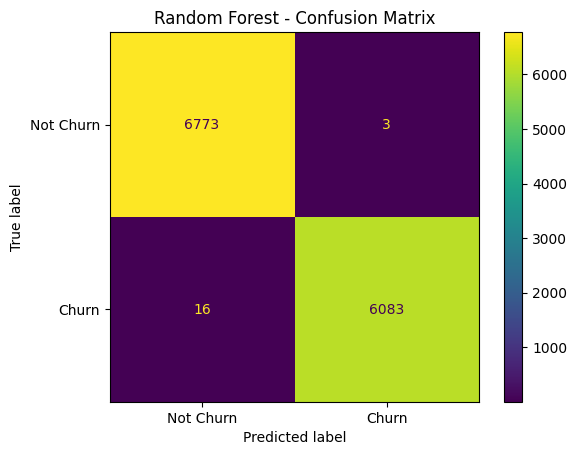

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Churn", "Churn"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

Classification Report

In [ ]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report")
print("------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Not Churn", "Churn"]
    )
)

Random Forest Classification Report
------------------------------------
              precision    recall  f1-score   support

   Not Churn       1.00      1.00      1.00      6776
       Churn       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



Feature Importance

In [ ]:
# Get feature names after preprocessing
feature_names = rf_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get importance values
importance_values = rf_pipeline.named_steps[
    "model"
].feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

# Sort
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Important Features:")
print(feature_importance.head(15))

Top 15 Important Features:
                            Feature  Importance
4                num__Payment Delay    0.434901
3                num__Support Calls    0.165593
1                       num__Tenure    0.115492
2              num__Usage Frequency    0.084602
5                  num__Total Spend    0.051998
0                          num__Age    0.040487
8                  cat__Gender_Male    0.032717
7                cat__Gender_Female    0.027171
6             num__Last Interaction    0.012991
13     cat__Contract Length_Monthly    0.012928
12      cat__Contract Length_Annual    0.008689
14   cat__Contract Length_Quarterly    0.006871
9      cat__Subscription Type_Basic    0.002176
10   cat__Subscription Type_Premium    0.001756
11  cat__Subscription Type_Standard    0.001628


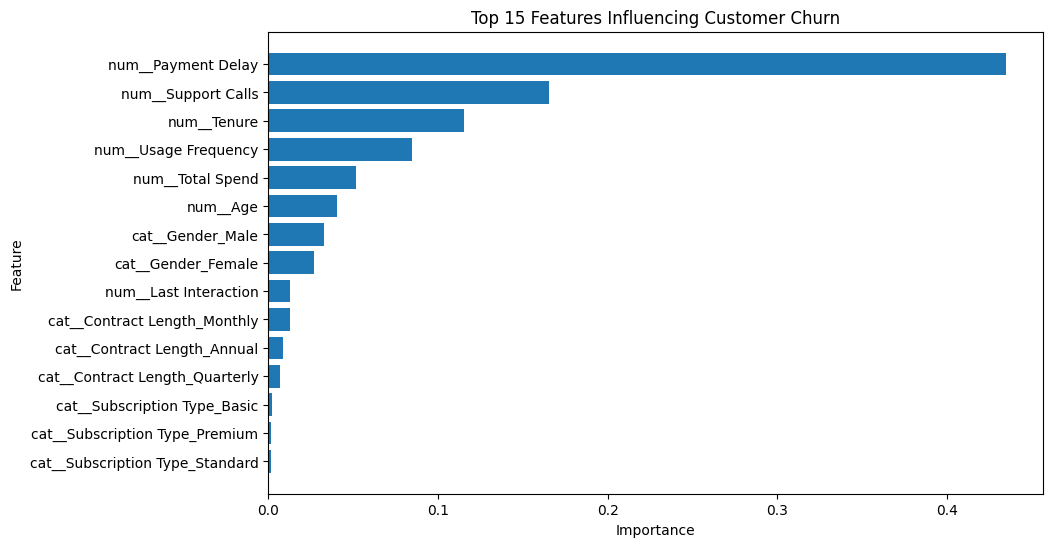

In [ ]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(15)

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing Customer Churn")
plt.show()

Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_grid,
    n_iter=8,
    cv=3,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting hyperparameter tuning...")

Starting hyperparameter tuning...


In [ ]:
random_search.fit(X_train, y_train)

print("\nTuning completed!")

print("\nBest Parameters:")
print(random_search.best_params_)

print(
    "\nBest Cross-Validation Accuracy:",
    round(random_search.best_score_ * 100, 2),
    "%"
)

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Tuning completed!

Best Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': 30}

Best Cross-Validation Accuracy: 99.77 %


Evaluate Tuned Model

In [ ]:
best_model = random_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

print("Tuned Random Forest Results")
print("---------------------------")

print(
    "Accuracy :",
    round(accuracy_score(y_test, y_pred_tuned) * 100, 2),
    "%"
)

print(
    "Precision:",
    round(precision_score(y_test, y_pred_tuned) * 100, 2),
    "%"
)

print(
    "Recall   :",
    round(recall_score(y_test, y_pred_tuned) * 100, 2),
    "%"
)

print(
    "F1 Score :",
    round(f1_score(y_test, y_pred_tuned) * 100, 2),
    "%"
)

Tuned Random Forest Results
---------------------------
Accuracy : 99.83 %
Precision: 99.93 %
Recall   : 99.7 %
F1 Score : 99.82 %


Compare Before vs After Tuning

In [ ]:
before_accuracy = accuracy_score(y_test, y_pred_rf) * 100
after_accuracy = accuracy_score(y_test, y_pred_tuned) * 100

comparison = pd.DataFrame({
    "Model": [
        "Random Forest Before Tuning",
        "Random Forest After Tuning"
    ],
    "Accuracy": [
        before_accuracy,
        after_accuracy
    ]
})

comparison["Accuracy"] = comparison["Accuracy"].round(2)

comparison

,Model,Accuracy
0,Random Forest Before Tuning,99.85
1,Random Forest After Tuning,99.83


Customer Churn Prediction Function

In [ ]:
def predict_customer_churn(customer_data):
    prediction = best_model.predict(customer_data)[0]
    probability = best_model.predict_proba(customer_data)[0]

    churn_probability = probability[1] * 100

    if prediction == 1:
        result = "HIGH RISK - CUSTOMER LIKELY TO CHURN"
    else:
        result = "LOW RISK - CUSTOMER LIKELY TO STAY"

    print("Prediction:", result)
    print("Churn Probability:", round(churn_probability, 2), "%")

    return prediction, churn_probability

Test

In [ ]:
sample_customer = X_test.iloc[[0]]

print("Sample Customer Data:")
display(sample_customer)

prediction, probability = predict_customer_churn(sample_customer)

Sample Customer Data:


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
7437,26,Male,51,19,6,3,Premium,Quarterly,761,21


Prediction: LOW RISK - CUSTOMER LIKELY TO STAY
Churn Probability: 0.0 %


Analyze All Test Customers

In [ ]:
# Get churn probabilities for all test customers
churn_probabilities = best_model.predict_proba(X_test)[:, 1]

risk_analysis = X_test.copy()

risk_analysis["Actual_Churn"] = y_test.values
risk_analysis["Churn_Probability"] = churn_probabilities

# Convert probability into percentage
risk_analysis["Churn_Probability"] = (
    risk_analysis["Churn_Probability"] * 100
)

# Risk category
risk_analysis["Risk_Level"] = pd.cut(
    risk_analysis["Churn_Probability"],
    bins=[-1, 30, 60, 100],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

print("Customer Risk Analysis:")
display(risk_analysis.head())

Customer Risk Analysis:


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Actual_Churn,Churn_Probability,Risk_Level
7437,26,Male,51,19,6,3,Premium,Quarterly,761,21,0,0.000000,Low Risk
54961,51,Female,7,4,7,0,Basic,Monthly,612,4,1,87.065476,High Risk
33685,52,Male,23,28,1,24,Premium,Annual,937,24,0,2.095238,Low Risk
20607,48,Male,57,30,10,0,Standard,Monthly,362,22,0,0.750000,Low Risk
34098,41,Female,45,27,5,9,Basic,Monthly,675,27,0,1.500000,Low Risk


Count Risk Categories

In [ ]:
print("Customer Risk Distribution:")

print(
    risk_analysis["Risk_Level"].value_counts()
)

Customer Risk Distribution:
Risk_Level
Low Risk       6698
High Risk      6051
Medium Risk     126
Name: count, dtype: int64


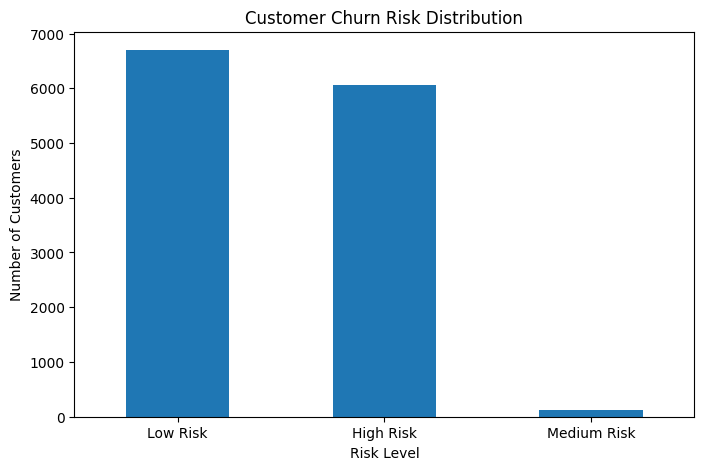

In [ ]:
plt.figure(figsize=(8, 5))

risk_analysis["Risk_Level"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

High-Risk Customers

In [ ]:
high_risk_customers = risk_analysis[
    risk_analysis["Risk_Level"] == "High Risk"
].sort_values(
    by="Churn_Probability",
    ascending=False
)

print(
    "Number of High-Risk Customers:",
    len(high_risk_customers)
)

display(high_risk_customers.head(10))

Number of High-Risk Customers: 6051


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Actual_Churn,Churn_Probability,Risk_Level
62542,58,Female,25,3,8,27,Premium,Monthly,531,10,1,100.0,High Risk
51847,26,Female,27,11,6,27,Premium,Quarterly,460,19,1,100.0,High Risk
10646,63,Female,50,18,5,25,Premium,Monthly,724,20,1,100.0,High Risk
53549,62,Female,37,4,7,28,Basic,Monthly,157,23,1,100.0,High Risk
48463,58,Female,37,13,6,29,Basic,Monthly,433,9,1,100.0,High Risk
5014,46,Female,37,22,10,26,Basic,Annual,829,27,1,100.0,High Risk
57511,54,Female,26,3,7,27,Standard,Monthly,772,22,1,100.0,High Risk
56512,64,Female,27,14,7,22,Basic,Annual,720,12,1,100.0,High Risk
51206,31,Female,28,6,8,28,Standard,Quarterly,183,20,1,100.0,High Risk
55225,47,Female,58,20,8,16,Premium,Annual,616,15,1,100.0,High Risk


Retention Recommendations

In [ ]:
def retention_recommendation(probability):
    if probability >= 80:
        return "Immediate retention offer, personal contact and service recovery"
    elif probability >= 60:
        return "Offer discount/upgrade and proactive customer support"
    elif probability >= 30:
        return "Send engagement offers and monitor customer activity"
    else:
        return "Maintain regular engagement and loyalty benefits"

risk_analysis["Retention_Recommendation"] = (
    risk_analysis["Churn_Probability"]
    .apply(retention_recommendation)
)

display(
    risk_analysis[
        [
            "Churn_Probability",
            "Risk_Level",
            "Retention_Recommendation"
        ]
    ].head(10)
)

,Churn_Probability,Risk_Level,Retention_Recommendation
7437,0.000000,Low Risk,Maintain regular engagement and loyalty benefits
54961,87.065476,High Risk,"Immediate retention offer, personal contact an..."
33685,2.095238,Low Risk,Maintain regular engagement and loyalty benefits
20607,0.750000,Low Risk,Maintain regular engagement and loyalty benefits
34098,1.500000,Low Risk,Maintain regular engagement and loyalty benefits
25054,3.233333,Low Risk,Maintain regular engagement and loyalty benefits
21914,0.500000,Low Risk,Maintain regular engagement and loyalty benefits
42952,0.333333,Low Risk,Maintain regular engagement and loyalty benefits
26694,1.325000,Low Risk,Maintain regular engagement and loyalty benefits
18601,1.000000,Low Risk,Maintain regular engagement and loyalty benefits


Save

In [ ]:
import joblib

joblib.dump(
    best_model,
    "customer_churn_prediction_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


Save High-Risk Customer Report

In [ ]:
high_risk_customers.to_csv(
    "high_risk_customers.csv",
    index=False
)

print("High-risk customer report saved successfully!")

High-risk customer report saved successfully!


Prediction System

In [ ]:
# Final Customer Churn Prediction System

def predict_customer(customer_data):
    """
    Predict whether a customer is likely to churn.
    customer_data should be a DataFrame containing the same input columns
    used during model training.
    """

    prediction = best_model.predict(customer_data)[0]

    if prediction == 1:
        result = "CUSTOMER LIKELY TO CHURN"
    else:
        result = "CUSTOMER LIKELY TO STAY"

    print("Prediction:", result)

    # Show probability if available
    if hasattr(best_model, "predict_proba"):
        probability = best_model.predict_proba(customer_data)[0]
        print("Prediction Probabilities:", probability)

    return result

In [ ]:
# Test the prediction system using one customer from the test dataset

sample_customer = X_test.iloc[[0]]

print("Sample Customer Prediction")
print("--------------------------")

predict_customer(sample_customer)

Sample Customer Prediction
--------------------------
Prediction: CUSTOMER LIKELY TO STAY
Prediction Probabilities: [1. 0.]


'CUSTOMER LIKELY TO STAY'

final performance summary

In [ ]:
# Final Model Performance Summary

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Predictions from final model
y_pred_final = best_model.predict(X_test)

final_accuracy = accuracy_score(y_test, y_pred_final) * 100
final_precision = precision_score(y_test, y_pred_final) * 100
final_recall = recall_score(y_test, y_pred_final) * 100
final_f1 = f1_score(y_test, y_pred_final) * 100

print("FINAL MODEL PERFORMANCE")
print("-----------------------")
print("Accuracy :", round(final_accuracy, 2), "%")
print("Precision:", round(final_precision, 2), "%")
print("Recall   :", round(final_recall, 2), "%")
print("F1 Score :", round(final_f1, 2), "%")

FINAL MODEL PERFORMANCE
-----------------------
Accuracy : 99.83 %
Precision: 99.93 %
Recall   : 99.7 %
F1 Score : 99.82 %


Final Business Recommendations

In [ ]:
# Final Business Recommendations

print("CUSTOMER RETENTION RECOMMENDATIONS")
print("----------------------------------")

recommendations = [
    "1. Identify high-risk customers and contact them proactively.",
    "2. Provide personalized offers or loyalty benefits to high-risk customers.",
    "3. Maintain regular engagement with customers through relevant communication.",
    "4. Monitor customer behavior and service usage for early signs of churn.",
    "5. Provide faster support and issue resolution to customers showing dissatisfaction.",
    "6. Use the churn prediction model regularly to prioritize retention efforts."
]

for recommendation in recommendations:
    print(recommendation)

CUSTOMER RETENTION RECOMMENDATIONS
----------------------------------
1. Identify high-risk customers and contact them proactively.
2. Provide personalized offers or loyalty benefits to high-risk customers.
3. Maintain regular engagement with customers through relevant communication.
4. Monitor customer behavior and service usage for early signs of churn.
5. Provide faster support and issue resolution to customers showing dissatisfaction.
6. Use the churn prediction model regularly to prioritize retention efforts.


Final Conclusion

In [ ]:
# Final Project Conclusion

print("PROJECT CONCLUSION")
print("------------------")

conclusion = """
The Customer Churn Prediction System was developed to identify customers
who are likely to leave a service. The dataset was analyzed, cleaned,
preprocessed, and used to train multiple machine learning models.

The final Random Forest model achieved:
- Accuracy: 99.83%
- Precision: 99.93%
- Recall: 99.70%
- F1 Score: 99.82%

The system can be used to identify potentially high-risk customers and
support proactive customer retention strategies. A customer risk report
was also generated, and the final trained model was saved for future use.

The prediction system demonstrates how machine learning can support
customer retention by identifying customers who may be at risk of churn
and helping businesses take appropriate retention actions.
"""

print(conclusion)

PROJECT CONCLUSION
------------------

The Customer Churn Prediction System was developed to identify customers
who are likely to leave a service. The dataset was analyzed, cleaned,
preprocessed, and used to train multiple machine learning models.

The final Random Forest model achieved:
- Accuracy: 99.83%
- Precision: 99.93%
- Recall: 99.70%
- F1 Score: 99.82%

The system can be used to identify potentially high-risk customers and
support proactive customer retention strategies. A customer risk report
was also generated, and the final trained model was saved for future use.

The prediction system demonstrates how machine learning can support
customer retention by identifying customers who may be at risk of churn
and helping businesses take appropriate retention actions.

